# Feature-based Pixel Classification + Random Forest

In [1]:
import os
import time
from glob import glob

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score

root_dir = r"C:\Users\52883\OneDrive\Desktop\A5\EWS-Dataset"
train_dir = os.path.join(root_dir, "train")
val_dir = os.path.join(root_dir, "validation")
test_dir = os.path.join(root_dir, "test")

## 1. Helper functions

In [2]:
def find_pairs(folder):
    pngs = sorted(glob(os.path.join(folder, "*.png")))
    pairs = []

    for f in pngs:
        if f.endswith("_mask.png"):
            continue

        mask_f = f[:-4] + "_mask.png"
        if os.path.exists(mask_f):
            pairs.append((f, mask_f))

    return pairs


def read_rgb(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Cannot read image: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def read_mask(path, th=250):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Cannot read mask: {path}")

    mask_bin = (mask < th).astype(np.uint8)
    return mask_bin


def quick_check(folder):
    pairs = find_pairs(folder)
    img_path, mask_path = pairs[0]

    img = read_rgb(img_path)
    mask = read_mask(mask_path)

    show = img.copy()
    show[mask == 1] = [255, 0, 0]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("RGB image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(show)
    plt.title("Overlay check")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


def pad_img(arr, pad):
    return np.pad(arr, ((pad, pad), (pad, pad), (0, 0)), mode="reflect")


def one_pixel_feat(img_rgb, img_hsv, y, x, patch=9):
    half = patch // 2

    rgb_pad = pad_img(img_rgb, half)
    hsv_pad = pad_img(img_hsv, half)

    yy = y + half
    xx = x + half

    rgb_crop = rgb_pad[yy-half:yy+half+1, xx-half:xx+half+1]
    hsv_crop = hsv_pad[yy-half:yy+half+1, xx-half:xx+half+1]

    rgb_mean = rgb_crop.reshape(-1, 3).mean(axis=0)
    rgb_std = rgb_crop.reshape(-1, 3).std(axis=0)

    hsv_mean = hsv_crop.reshape(-1, 3).mean(axis=0)
    hsv_std = hsv_crop.reshape(-1, 3).std(axis=0)

    rgb_mid = img_rgb[y, x].astype(np.float32)
    hsv_mid = img_hsv[y, x].astype(np.float32)

    feat = np.concatenate([
        rgb_mean, rgb_std,
        hsv_mean, hsv_std,
        rgb_mid, hsv_mid
    ]).astype(np.float32)

    return feat


def pick_train_points(mask, n_plant=300, n_bg=300, seed=42):
    rng = np.random.default_rng(seed)

    plant_pts = np.argwhere(mask == 1)
    bg_pts = np.argwhere(mask == 0)

    if len(plant_pts) > n_plant:
        plant_pts = plant_pts[rng.choice(len(plant_pts), n_plant, replace=False)]

    if len(bg_pts) > n_bg:
        bg_pts = bg_pts[rng.choice(len(bg_pts), n_bg, replace=False)]

    return plant_pts, bg_pts


def make_train_data(folder, patch=9, n_plant=300, n_bg=300):
    pairs = find_pairs(folder)

    X = []
    y = []

    for i, (img_path, mask_path) in enumerate(pairs):
        img = read_rgb(img_path)
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        mask = read_mask(mask_path)

        plant_pts, bg_pts = pick_train_points(
            mask,
            n_plant=n_plant,
            n_bg=n_bg,
            seed=42 + i
        )

        for yy, xx in plant_pts:
            X.append(one_pixel_feat(img, hsv, yy, xx, patch=patch))
            y.append(1)

        for yy, xx in bg_pts:
            X.append(one_pixel_feat(img, hsv, yy, xx, patch=patch))
            y.append(0)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.uint8)

    return X, y

In [3]:
def fit_rf(X, y):
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    )
    model.fit(X, y)
    return model


def predict_one(model, img_rgb, patch=9, prob_th=0.54):
    h, w, _ = img_rgb.shape
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

    pred = np.zeros((h, w), dtype=np.uint8)

    for yy in range(h):
        row_x = []
        for xx in range(w):
            row_x.append(one_pixel_feat(img_rgb, hsv, yy, xx, patch=patch))

        row_x = np.array(row_x, dtype=np.float32)
        row_prob = model.predict_proba(row_x)[:, 1]
        pred[yy, :] = (row_prob >= prob_th).astype(np.uint8)

    return pred


def clean_mask(mask):
    cross_k = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))

    a = cv2.morphologyEx(mask, cv2.MORPH_OPEN, cross_k)
    b = cv2.morphologyEx(a, cv2.MORPH_CLOSE, cross_k)

    thin_k = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
    c = cv2.erode(b, thin_k, iterations=1)

    return c


def get_scores(gt, pred):
    gt = gt.flatten()
    pred = pred.flatten()

    p = precision_score(gt, pred, zero_division=0)
    r = recall_score(gt, pred, zero_division=0)
    f1 = f1_score(gt, pred, zero_division=0)
    iou = jaccard_score(gt, pred, zero_division=0)

    return p, r, f1, iou


def show_result(img, gt, pred, title_text=None):
    overlay = img.copy()
    overlay[pred == 1] = [255, 0, 0]

    plt.figure(figsize=(16, 4))
    if title_text is not None:
        plt.suptitle(title_text, fontsize=13)

    plt.subplot(1, 4, 1)
    plt.imshow(img)
    plt.title("RGB image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(gt, cmap="gray")
    plt.title("GT mask")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(pred, cmap="gray")
    plt.title("Pred mask")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(overlay)
    plt.title("Pred overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


def eval_all_pairs(model, pairs, patch=9, prob_th=0.54, split_name="Validation", keep_details=False):
    if len(pairs) == 0:
        raise ValueError("No image-mask pairs found.")

    p_list = []
    r_list = []
    f1_list = []
    iou_list = []
    time_list = []
    details = []

    for i, (img_path, mask_path) in enumerate(pairs):
        img = read_rgb(img_path)
        gt = read_mask(mask_path)

        t0 = time.time()
        pred = predict_one(model, img, patch=patch, prob_th=prob_th)
        pred = clean_mask(pred)
        pred_time = time.time() - t0

        p, r, f1, iou = get_scores(gt, pred)

        p_list.append(p)
        r_list.append(r)
        f1_list.append(f1)
        iou_list.append(iou)
        time_list.append(pred_time)

        if keep_details:
            details.append({
                "name": os.path.basename(img_path),
                "img": img,
                "gt": gt,
                "pred": pred,
                "precision": p,
                "recall": r,
                "f1": f1,
                "iou": iou,
                "time": pred_time
            })

    result = {
        "precision": np.mean(p_list),
        "recall": np.mean(r_list),
        "f1": np.mean(f1_list),
        "iou": np.mean(iou_list),
        "total_time": np.sum(time_list),
        "avg_time": np.mean(time_list),
        "num_images": len(pairs)
    }

    if keep_details:
        result["details"] = details

    return result


def print_result(result, split_name):
    print(f"\n{split_name} mean metrics ({result['num_images']} images):")
    print(f"Precision: {result['precision']:.4f}")
    print(f"Recall:    {result['recall']:.4f}")
    print(f"F1-score:  {result['f1']:.4f}")
    print(f"IoU:       {result['iou']:.4f}")
    print(f"Total prediction time: {result['total_time']:.2f} seconds")
    print(f"Average prediction time per image: {result['avg_time']:.2f} seconds")


def pick_representative_cases(details):
    details_sorted = sorted(details, key=lambda x: x['iou'])
    worst_case = details_sorted[0]
    typical_case = details_sorted[len(details_sorted) // 2]
    best_case = details_sorted[-1]

    return {
        'best': best_case,
        'typical': typical_case,
        'worst': worst_case
    }


def show_representative_cases(case_dict, split_name='Test'):
    print(f"Best example: {case_dict['best']['name']} | IoU = {case_dict['best']['iou']:.4f}")
    show_result(case_dict['best']['img'], case_dict['best']['gt'], case_dict['best']['pred'],
                title_text=f"{split_name} - Best result")

    print(f"Typical example: {case_dict['typical']['name']} | IoU = {case_dict['typical']['iou']:.4f}")
    show_result(case_dict['typical']['img'], case_dict['typical']['gt'], case_dict['typical']['pred'],
                title_text=f"{split_name} - Typical result")

    print(f"Failure example: {case_dict['worst']['name']} | IoU = {case_dict['worst']['iou']:.4f}")
    show_result(case_dict['worst']['img'], case_dict['worst']['gt'], case_dict['worst']['pred'],
                title_text=f"{split_name} - Failed result")

## 2. Set parameters

In [4]:
patch_size = 6
plant_num = 300
bg_num = 300
prob_th = 0.53

## 3. Load the dataset splits and train the model

In [5]:
train_pairs = find_pairs(train_dir)
val_pairs = find_pairs(val_dir)
test_pairs = find_pairs(test_dir)

print("Train images:", len(train_pairs))
print("Validation images:", len(val_pairs))
print("Test images:", len(test_pairs))

X_train, y_train = make_train_data(
    train_dir,
    patch=patch_size,
    n_plant=plant_num,
    n_bg=bg_num
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

t1 = time.time()
rf = fit_rf(X_train, y_train)
train_time = time.time() - t1
print(f"Training time: {train_time:.2f} seconds")

Train images: 142
Validation images: 24
Test images: 24
X_train shape: (85200, 18)
y_train shape: (85200,)
Training time: 3.00 seconds


## 4. Validation results

In [6]:
val_result = eval_all_pairs(
    rf,
    val_pairs,
    patch=patch_size,
    prob_th=prob_th,
    split_name="Validation"
)

print_result(val_result, "Validation")


Validation mean metrics (24 images):
Precision: 0.8344
Recall:    0.7376
F1-score:  0.7719
IoU:       0.6471
Total prediction time: 803.55 seconds
Average prediction time per image: 33.48 seconds


## 5. Test results

In [7]:
test_result = eval_all_pairs(
    rf,
    test_pairs,
    patch=patch_size,
    prob_th=prob_th,
    split_name="Test",
    keep_details=True
)

print_result(test_result, "Test")


Test mean metrics (24 images):
Precision: 0.8285
Recall:    0.7624
F1-score:  0.7834
IoU:       0.6651
Total prediction time: 771.61 seconds
Average prediction time per image: 32.15 seconds


## 6. Representative test results

Best example: FPWW0180151_RGB1_20170420_130936_6.png | IoU = 0.9008


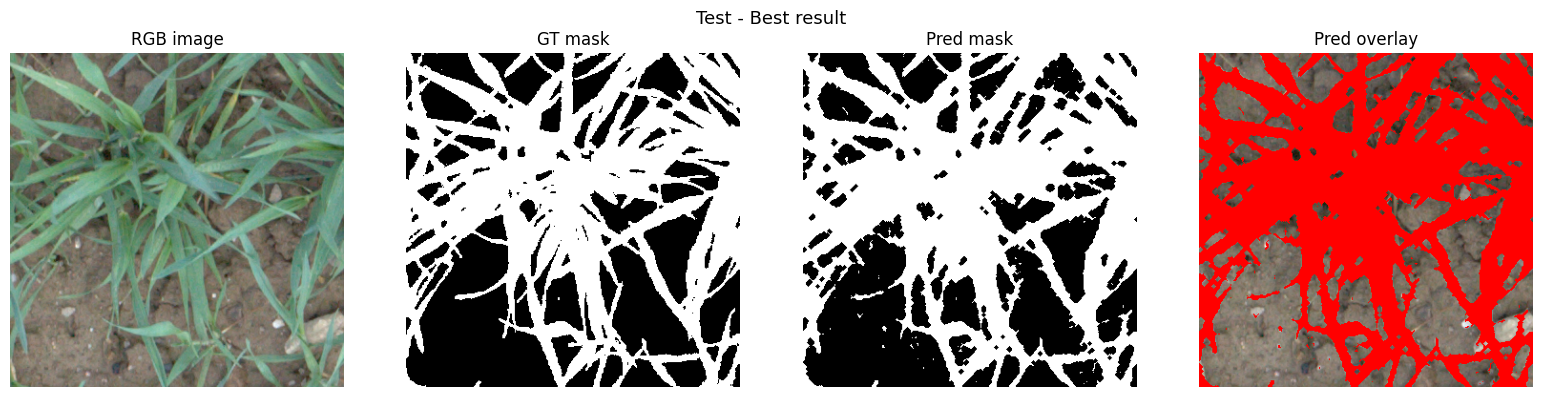

Typical example: FPWW0180665_RGB1_20170510_162129_6.png | IoU = 0.7050


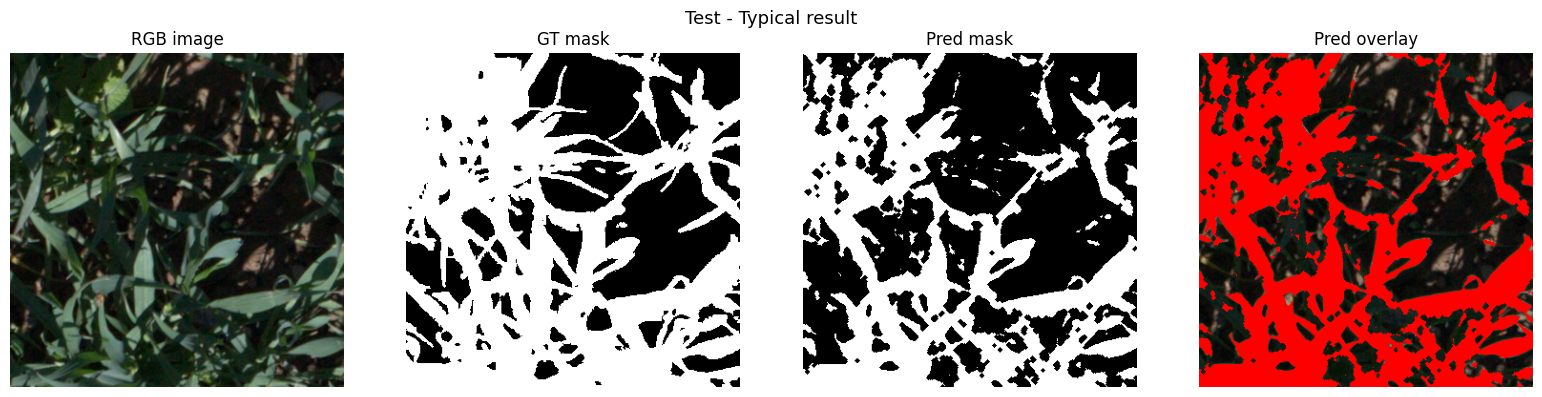

Failure example: FPWW0180374_RGB1_20170222_133502_6.png | IoU = 0.1676


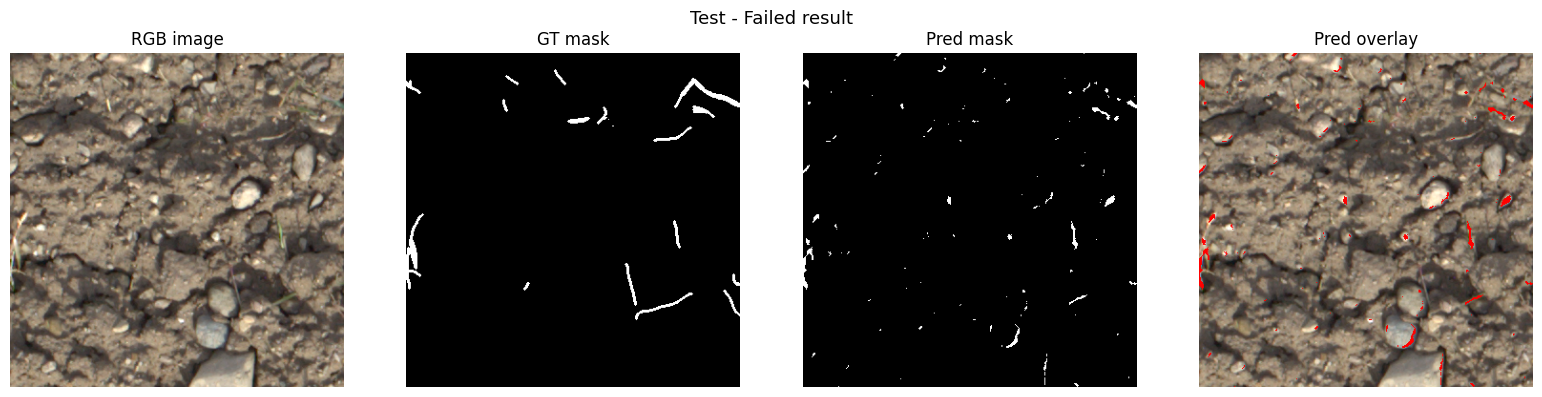

In [8]:
test_cases = pick_representative_cases(test_result['details'])
show_representative_cases(test_cases, split_name='Test')